# Low Chin Tone Detection from EMG Signal

This notebook analyzes EMG signals (9th channel) to detect low chin tone periods.
- Divides 30-second epochs into 10 segments of 3 seconds each
- Calculates energy for each segment
- Determines threshold based on REM stage statistics
- Visualizes results with statistical graphs and epoch plots

In [36]:
import random
import torch
import torch.nn as nn
import numpy as np
import pickle
import os
import natsort
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import timedelta
import datetime as dt

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(5)
np.random.seed(5)
random.seed(5)

In [37]:
def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise ValueError('Boolean value expected.')

In [38]:
class EMGDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, label_list, num_channels=9, fs=50):
        self.data_list = [torch.tensor(data[:, :, :num_channels], dtype=torch.float32) for data in data_list]
        self.label_list = [torch.tensor(labels, dtype=torch.long) for labels in label_list]
        self.num_data = [data.shape[0] for data in self.data_list]
        self.data_list = torch.concat(self.data_list, dim=0).unsqueeze(1)
        self.label_list = torch.concat(self.label_list, dim=0)
        self.num_channels = num_channels
        self.fs = fs
        
        # Group data (keeping original grouping from evaluate_demo.py)
        self.data_list, self.label_list = self._group_data(self.data_list, self.label_list, 1)
        self._permute_data()

    def _group_data(self, data, labels, n):
        grouped_data = []
        grouped_labels = []
        for idx in range(0, len(data) - n + 1):
            grouped_data.append(data[idx:idx+n]) 
            grouped_labels.append(labels[idx+n-1])
        
        grouped_data = torch.stack(grouped_data)
        grouped_labels = torch.tensor(grouped_labels, dtype=torch.long)
        
        return grouped_data, grouped_labels

    def _permute_data(self):     
        self.data_list = self.data_list.reshape(-1, 1, self.data_list.size(3), self.data_list.size(4))
        self.data_list = self.data_list.permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        data = self.data_list[idx]
        label = self.label_list[idx]
        return data, label

In [39]:
def calculate_emg_energy(emg_signal, segment_length=150):
    """
    Calculate energy for 3-second segments of EMG signal
    
    Args:
        emg_signal: EMG signal (1500 samples for 30 seconds at 50Hz)
        segment_length: Length of each segment (150 samples = 3 seconds at 50Hz)
    
    Returns:
        energy_values: Array of 10 energy values for each 3-second segment
    """
    energy_values = []
    
    for i in range(0, len(emg_signal), segment_length):
        segment = emg_signal[i:i+segment_length]
        if len(segment) == segment_length:
            # Calculate RMS energy
            energy = np.sqrt(np.mean(segment**2))
            energy_values.append(energy)
    
    return np.array(energy_values)

In [40]:
def determine_low_chin_threshold(rem_energy_values, percentile=25):
    """
    Determine threshold for low chin tone based on REM stage statistics
    
    Args:
        rem_energy_values: Energy values from REM stages
        percentile: Percentile to use as threshold (lower percentile = more sensitive)
    
    Returns:
        threshold: Energy threshold for low chin tone detection
    """
    if len(rem_energy_values) > 0:
        threshold = np.percentile(rem_energy_values, percentile)
    else:
        threshold = 0.5  # Default threshold if no REM data available
    
    return threshold

In [41]:
def classify_low_chin_tone(energy_values, threshold):
    """
    Classify 3-second segments as low chin tone or not
    
    Args:
        energy_values: Array of energy values for 10 segments
        threshold: Energy threshold
    
    Returns:
        classifications: Boolean array indicating low chin tone (True) or not (False)
    """
    return energy_values < threshold

In [42]:
def create_low_chin_labels(classifications, fs=50, segment_length=150):
    """
    Create continuous low chin tone labels from 3-second segment classifications
    
    Args:
        classifications: Boolean array of low chin tone classifications for each epoch
        fs: Sampling frequency (default: 50Hz)
        segment_length: Length of each segment in samples (default: 150 = 3 seconds)
    
    Returns:
        y: Binary array indicating low chin tone periods (1500 samples per epoch)
    """
    y = np.zeros(1500, dtype=np.float32)  # 30 seconds at 50Hz
    
    for i, is_low_chin in enumerate(classifications):
        start_idx = i * segment_length
        end_idx = start_idx + segment_length
        if is_low_chin:
            y[start_idx:end_idx] = 1.0
    
    return y

In [ ]:
def load_sleep_stage_xml(xml_path):
    """
    Load sleep stage XML and return the first epoch onset time
    
    Args:
        xml_path: Path to the SLEEP XML file
    
    Returns:
        first_epoch_onset: datetime object of the first epoch
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # Find the first annotation
        first_annotation = root.find("annotation")
        if first_annotation is not None:
            onset_text = first_annotation.find("onset").text
            # Parse the onset time
            first_epoch_onset = dt.datetime.strptime(onset_text, "%Y-%m-%dT%H:%M:%S.%f")
            return first_epoch_onset
        else:
            print(f"No annotations found in {xml_path}")
            return None
    except Exception as e:
        print(f"Error reading SLEEP XML {xml_path}: {e}")
        return None

def save_low_chin_xml(meas_date, y_all_epochs, sfreq, xml_save_path, 
                       description="LOW_CHIN_TONE", location="EEG-EMG", min_duration=1.0):
    """
    Save low chin tone events to XML file
    
    Args:
        meas_date: Recording start datetime (first epoch onset)
        y_all_epochs: Concatenated binary labels for all epochs
        sfreq: Sampling frequency (default: 50Hz)
        xml_save_path: Path to save XML file
        description: Event description (default: "LOW_CHIN_TONE")
        location: Channel location (default: "EEG-EMG")
        min_duration: Minimum duration for events in seconds (default: 1.0)
    """
    # Find continuous periods of low chin tone
    diff_y = np.diff(np.concatenate([[0], y_all_epochs, [0]]))  
    start_points = np.where(diff_y == 1)[0]
    end_points = np.where(diff_y == -1)[0]

    root = ET.Element("annotationlist")
    
    # Add recording duration (but remove recording_start_time)
    recording_duration = len(y_all_epochs) / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"

    event_count = 0
    for start_idx, end_idx in zip(start_points, end_points):
        start_sec = start_idx / sfreq
        end_sec = end_idx / sfreq
        duration = end_sec - start_sec

        # Only include events longer than minimum duration
        if duration < min_duration:
            continue

        # Calculate onset time relative to the first epoch onset
        onset_time = meas_date + timedelta(seconds=start_sec)

        annotation = ET.SubElement(root, "annotation")

        onset_elem = ET.SubElement(annotation, "onset")
        onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")

        duration_elem = ET.SubElement(annotation, "duration")
        duration_elem.text = f"{duration:.6f}"

        desc_elem = ET.SubElement(annotation, "description")
        desc_elem.text = description

        location_elem = ET.SubElement(annotation, "location")
        location_elem.text = location
        
        event_count += 1

    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)

    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count

In [ ]:
# Configuration
num_channels = 9
fs = 50
emg_channel_idx = 8  # EMG is the 9th channel (0-indexed)
segment_length = 150  # 3 seconds at 50Hz
epoch_length = 1500   # 30 seconds at 50Hz

# Dataset paths - Choose which dataset to use
# Option 1: CND Dataset
# dataset_dir = f'/home/honeynaps/data/250718_CND/PICKLE/SLEEP_50_NOFILL_NOPREP'
# sleep_xml_dir = f'/home/honeynaps/data/250718_CND/EBX/SLEEP'

# Option 2: GOLDEN Dataset (currently active)
dataset_dir = f'/home/honeynaps/data/GOLDEN/PICKLE/SLEEP_50_NOFILL'
sleep_xml_dir = f'/home/honeynaps/data/GOLDEN/EBX2/SLEEP'

print(f"Dataset directory: {dataset_dir}")
print(f"SLEEP XML directory: {sleep_xml_dir}")

if os.path.exists(dataset_dir):
    file_names = natsort.natsorted(os.listdir(dataset_dir))
    print(f"Found {len(file_names)} pickle files")
else:
    print("Dataset directory not found!")
    file_names = []

if os.path.exists(sleep_xml_dir):
    xml_files = natsort.natsorted([f for f in os.listdir(sleep_xml_dir) if f.endswith('.xml')])
    print(f"Found {len(xml_files)} SLEEP XML files")
else:
    print("SLEEP XML directory not found!")
    xml_files = []

In [45]:
# Load data and extract EMG signals with sleep stage labels
all_emg_data = []
all_energy_values = []
all_sleep_stages = []
rem_energy_values = []
file_data_mapping = []  # Store file information for each epoch

print("Loading data and calculating EMG energy...")

for file_idx, file_name in enumerate(file_names[:5]):  # Process first 5 files
    print(f"Processing file {file_idx + 1}/5: {file_name}")
    
    with open(os.path.join(dataset_dir, file_name), 'rb') as f:
        data_dict = pickle.load(f)
    
    # Extract data
    data = data_dict['x']  # Shape: (n_epochs, epoch_length, n_channels)
    labels = data_dict['y']  # Sleep stage labels
    
    # Process each epoch
    file_start_idx = len(all_emg_data)  # Track where this file's data starts
    for epoch_idx in range(len(data)):
        emg_signal = data[epoch_idx][:, emg_channel_idx]  # Extract EMG channel
        sleep_stage = int(labels[epoch_idx])
        
        # Calculate energy for 10 segments of 3 seconds each
        energy_values = calculate_emg_energy(emg_signal, segment_length)
        
        if len(energy_values) == 10:  # Ensure we have exactly 10 segments
            all_emg_data.append(emg_signal)
            all_energy_values.extend(energy_values)
            all_sleep_stages.extend([sleep_stage] * 10)
            file_data_mapping.append({'file_idx': file_idx, 'file_name': file_name, 'local_epoch_idx': epoch_idx})
            
            # Collect REM energy values for threshold calculation
            if sleep_stage == 1:  # REM stage
                rem_energy_values.extend(energy_values)

all_emg_data = np.array(all_emg_data)
all_energy_values = np.array(all_energy_values)
all_sleep_stages = np.array(all_sleep_stages)
rem_energy_values = np.array(rem_energy_values)

print(f"Total epochs processed: {len(all_emg_data)}")
print(f"Total 3-second segments: {len(all_energy_values)}")
print(f"REM segments for threshold calculation: {len(rem_energy_values)}")

Loading data and calculating EMG energy...
Processing file 1/5: SCH_F_20_OB_231128R4_NO.pickle
Processing file 2/5: SCH_F_20_OV_230715R3_MO.pickle
Processing file 3/5: SCH_F_40_NW_230511R3_SE.pickle
Processing file 4/5: SCH_F_40_NW_231130R4_MO.pickle
Processing file 4/5: SCH_F_40_NW_231130R4_MO.pickle
Processing file 5/5: SCH_F_40_OB_231125R4_SE.pickle
Total epochs processed: 4231
Total 3-second segments: 42310
REM segments for threshold calculation: 6640


In [46]:
# Calculate threshold based on REM statistics
# Using 75th percentile for more relaxed threshold (was 25th)
threshold_percentile = 75  # More relaxed threshold
threshold = determine_low_chin_threshold(rem_energy_values, percentile=threshold_percentile)
print(f"Low chin tone threshold: {threshold:.4f} (using {threshold_percentile}th percentile)")

# Basic statistics
if len(rem_energy_values) > 0:
    print(f"REM energy statistics:")
    print(f"  Mean: {np.mean(rem_energy_values):.4f}")
    print(f"  Std: {np.std(rem_energy_values):.4f}")
    print(f"  25th percentile: {np.percentile(rem_energy_values, 25):.4f}")
    print(f"  40th percentile: {np.percentile(rem_energy_values, 40):.4f}")
    print(f"  50th percentile: {np.percentile(rem_energy_values, 50):.4f}")
    print(f"  75th percentile: {np.percentile(rem_energy_values, 75):.4f}")
    print(f"\nNote: Using {threshold_percentile}th percentile for more relaxed low chin tone detection")

Low chin tone threshold: 0.5346 (using 75th percentile)
REM energy statistics:
  Mean: 0.4716
  Std: 0.2797
  25th percentile: 0.3118
  40th percentile: 0.3878
  50th percentile: 0.4309
  75th percentile: 0.5346

Note: Using 75th percentile for more relaxed low chin tone detection


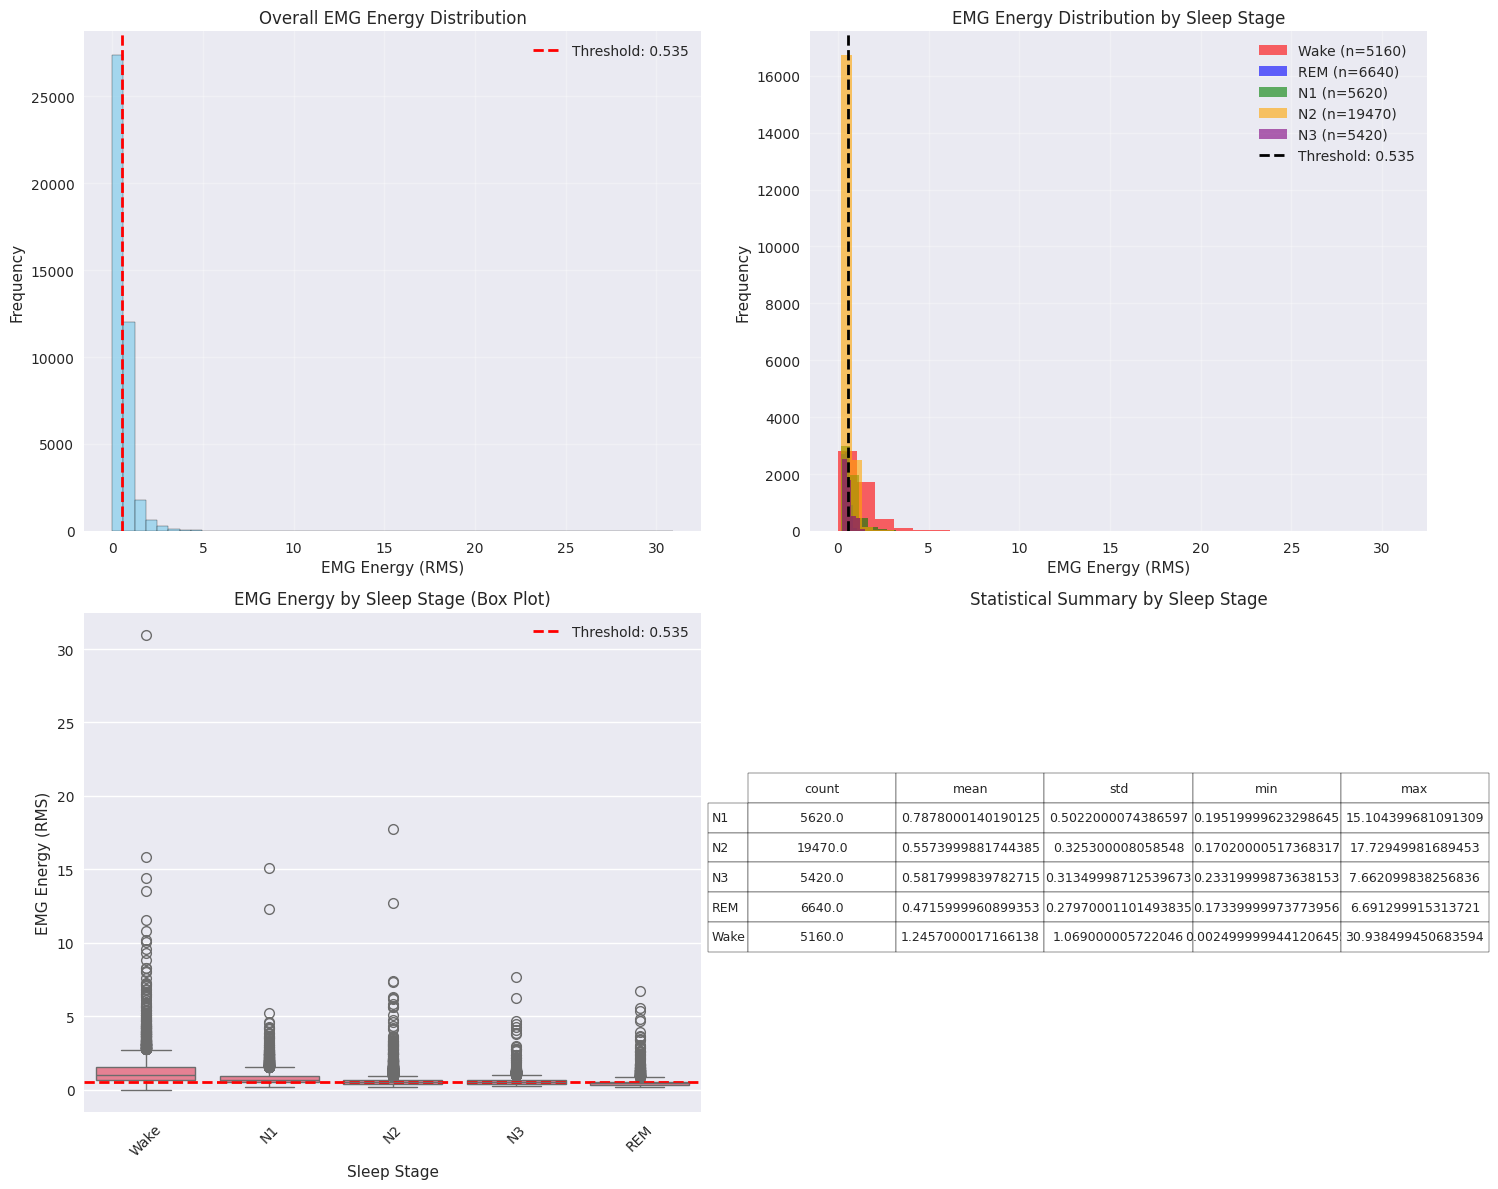


Detailed Statistics by Sleep Stage:
            count    mean     std     min        max
stage_name                                          
N1           5620  0.7878  0.5022  0.1952  15.104400
N2          19470  0.5574  0.3253  0.1702  17.729500
N3           5420  0.5818  0.3135  0.2332   7.662100
REM          6640  0.4716  0.2797  0.1734   6.691300
Wake         5160  1.2457  1.0690  0.0025  30.938499


In [47]:
# Statistical Analysis and Visualization
sleep_stage_names = ['Wake', 'REM', 'N1', 'N2', 'N3']

# Create DataFrame for analysis
df = pd.DataFrame({
    'energy': all_energy_values,
    'sleep_stage': all_sleep_stages,
    'stage_name': [sleep_stage_names[int(stage)] for stage in all_sleep_stages]  # Fix: convert to int
})

# Overall energy distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Overall energy histogram
axes[0, 0].hist(all_energy_values, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
axes[0, 0].set_xlabel('EMG Energy (RMS)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall EMG Energy Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Energy distribution by sleep stage
stage_colors = ['red', 'blue', 'green', 'orange', 'purple']
for stage in range(5):
    stage_data = df[df['sleep_stage'] == stage]['energy']
    if len(stage_data) > 0:
        axes[0, 1].hist(stage_data, bins=30, alpha=0.6, 
                       label=f'{sleep_stage_names[stage]} (n={len(stage_data)})',
                       color=stage_colors[stage])

axes[0, 1].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
axes[0, 1].set_xlabel('EMG Energy (RMS)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('EMG Energy Distribution by Sleep Stage')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Box plot by sleep stage
sns.boxplot(data=df, x='stage_name', y='energy', ax=axes[1, 0])
axes[1, 0].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
axes[1, 0].set_xlabel('Sleep Stage')
axes[1, 0].set_ylabel('EMG Energy (RMS)')
axes[1, 0].set_title('EMG Energy by Sleep Stage (Box Plot)')
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Statistical summary table
stats_summary = df.groupby('stage_name')['energy'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=stats_summary.values, 
                        rowLabels=stats_summary.index,
                        colLabels=stats_summary.columns,
                        cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Statistical Summary by Sleep Stage')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nDetailed Statistics by Sleep Stage:")
print(stats_summary)

In [48]:
# Classify all segments for low chin tone
low_chin_classifications = all_energy_values < threshold

# Calculate percentages
total_segments = len(all_energy_values)
low_chin_count = np.sum(low_chin_classifications)
low_chin_percentage = (low_chin_count / total_segments) * 100

print(f"\nLow Chin Tone Detection Results:")
print(f"Total 3-second segments: {total_segments}")
print(f"Low chin tone segments: {low_chin_count} ({low_chin_percentage:.1f}%)")
print(f"Normal chin tone segments: {total_segments - low_chin_count} ({100 - low_chin_percentage:.1f}%)")

# Breakdown by sleep stage
print(f"\nLow Chin Tone by Sleep Stage:")
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        stage_total = np.sum(stage_mask)
        stage_low_chin = np.sum(low_chin_classifications[stage_mask])
        stage_percentage = (stage_low_chin / stage_total) * 100 if stage_total > 0 else 0
        print(f"  {sleep_stage_names[stage]}: {stage_low_chin}/{stage_total} ({stage_percentage:.1f}%)")


Low Chin Tone Detection Results:
Total 3-second segments: 42310
Low chin tone segments: 21646 (51.2%)
Normal chin tone segments: 20664 (48.8%)

Low Chin Tone by Sleep Stage:
  Wake: 580/5160 (11.2%)
  REM: 4980/6640 (75.0%)
  N1: 1519/5620 (27.0%)
  N2: 11369/19470 (58.4%)
  N3: 3198/5420 (59.0%)


In [49]:
# Visualization of 30-second epochs with low chin tone classifications
def plot_epoch_with_classifications(epoch_data, energy_values, classifications, epoch_idx, sleep_stage, threshold):
    """
    Plot 30-second epoch with 10 segment classifications
    """
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))
    
    # Time axis
    time_axis = np.arange(len(epoch_data)) / fs
    
    # 1. Raw EMG signal
    ax1.plot(time_axis, epoch_data, 'b-', linewidth=0.5)
    ax1.set_ylabel('EMG Amplitude')
    ax1.set_title(f'Epoch {epoch_idx + 1}: {sleep_stage_names[int(sleep_stage)]} Stage - EMG Signal')  # Fix: convert to int
    ax1.grid(True, alpha=0.3)
    
    # Add vertical lines to show 3-second segments
    for i in range(1, 10):
        ax1.axvline(i * 3, color='gray', linestyle=':', alpha=0.5)
    
    # Color background based on classifications
    for i in range(10):
        start_time = i * 3
        end_time = (i + 1) * 3
        if classifications[i]:
            ax1.axvspan(start_time, end_time, alpha=0.2, color='red', label='Low Chin Tone' if i == 0 else "")
        else:
            ax1.axvspan(start_time, end_time, alpha=0.2, color='green', label='Normal Chin Tone' if i == 0 else "")
    
    if epoch_idx == 0:  # Only show legend on first plot
        ax1.legend()
    
    # 2. Energy values for each 3-second segment
    segment_times = np.arange(10) * 3 + 1.5  # Center of each 3-second segment
    colors = ['red' if c else 'green' for c in classifications]
    bars = ax2.bar(segment_times, energy_values, width=2.5, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.3f}')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('EMG Energy (RMS)')
    ax2.set_title('Energy Values for 3-second Segments')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 30)
    
    # Add energy values as text on bars
    for i, (bar, energy) in enumerate(zip(bars, energy_values)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{energy:.2f}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    # 3. Classification summary
    classification_labels = ['Low Chin' if c else 'Normal' for c in classifications]
    ax3.bar(segment_times, [1]*10, width=2.5, color=colors, alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Time (seconds)')
    ax3.set_ylabel('Classification')
    ax3.set_title('Low Chin Tone Classification per 3-second Segment')
    ax3.set_ylim(0, 1.2)
    ax3.set_xlim(0, 30)
    ax3.set_yticks([])
    
    # Add classification labels
    for i, (time, label) in enumerate(zip(segment_times, classification_labels)):
        ax3.text(time, 0.5, label, ha='center', va='center', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Select 5 representative epochs for visualization
selected_epochs = []
epochs_per_stage = {}

# Try to get one epoch from each sleep stage
epoch_counter = 0
for epoch_idx in range(len(all_emg_data)):
    if len(selected_epochs) >= 5:
        break
    
    # Get sleep stage for this epoch (use first segment's stage)
    sleep_stage = all_sleep_stages[epoch_idx * 10]
    
    # Try to get variety in sleep stages
    if sleep_stage not in epochs_per_stage or len(selected_epochs) >= 3:
        selected_epochs.append(epoch_idx)
        epochs_per_stage[sleep_stage] = epochs_per_stage.get(sleep_stage, 0) + 1

print(f"Selected epochs for visualization: {len(selected_epochs)}")
print("Sleep stages represented:", [sleep_stage_names[int(all_sleep_stages[idx * 10])] for idx in selected_epochs])  # Fix: convert to int

Selected epochs for visualization: 5
Sleep stages represented: ['Wake', 'N1', 'N2', 'N1', 'N2']


In [ ]:
# Generate XML output for each individual file
print("\n" + "="*60)
print("GENERATING XML OUTPUT FOR EACH FILE")
print("="*60)

# Save XML output directory
xml_output_dir = "/home/honeynaps/data/shared/integrate/output"
os.makedirs(xml_output_dir, exist_ok=True)

# Process each file separately
file_results = {}
for file_idx in range(len(file_names[:5])):
    current_file_name = file_names[file_idx]
    base_name = current_file_name.replace('.pickle', '')
    
    # Find corresponding SLEEP XML file
    sleep_xml_name = f"{base_name}_SLEEP.xml"
    sleep_xml_path = os.path.join(sleep_xml_dir, sleep_xml_name)
    
    # Load first epoch onset from SLEEP XML
    first_epoch_onset = None
    if os.path.exists(sleep_xml_path):
        first_epoch_onset = load_sleep_stage_xml(sleep_xml_path)
        print(f"\nProcessing file {file_idx + 1}/5: {current_file_name}")
        print(f"  Corresponding SLEEP XML: {sleep_xml_name}")
        if first_epoch_onset:
            print(f"  First epoch onset: {first_epoch_onset.strftime('%Y-%m-%d %H:%M:%S')}")
    else:
        print(f"\nWarning: SLEEP XML not found for {current_file_name}")
        print(f"  Expected: {sleep_xml_path}")
        # Use default datetime if SLEEP XML not found
        first_epoch_onset = dt.datetime(2024, 1, 1, 22, 0, 0)
    
    # Collect epochs for this file
    file_epochs = []
    file_epoch_indices = []
    
    for epoch_idx, mapping in enumerate(file_data_mapping):
        if mapping['file_idx'] == file_idx:
            file_epochs.append(all_emg_data[epoch_idx])
            file_epoch_indices.append(epoch_idx)
    
    if len(file_epochs) == 0:
        print(f"No epochs found for file: {current_file_name}")
        continue
    
    print(f"  Number of epochs: {len(file_epochs)}")
    
    # Create continuous labels for this file
    file_epoch_labels = []
    
    for epoch_data in file_epochs:
        # Calculate energy values for this epoch
        epoch_energy_values = calculate_emg_energy(epoch_data, segment_length)
        
        # Get classifications using relaxed threshold
        epoch_classifications = classify_low_chin_tone(epoch_energy_values, threshold)
        
        # Create continuous labels for this epoch
        epoch_labels = create_low_chin_labels(epoch_classifications, fs, segment_length)
        file_epoch_labels.append(epoch_labels)
    
    # Concatenate all epoch labels for this file
    y_continuous_file = np.concatenate(file_epoch_labels)
    
    # Generate XML filename for this file
    xml_filename = f"{base_name}_CHIN.xml"
    xml_save_path = os.path.join(xml_output_dir, xml_filename)
    
    # Save XML with low chin tone events for this file using correct onset
    event_count = save_low_chin_xml(
        meas_date=first_epoch_onset,
        y_all_epochs=y_continuous_file,
        sfreq=fs,
        xml_save_path=xml_save_path,
        description="LOW_CHIN_TONE",
        location="EEG-EMG",
        min_duration=1.0  # Minimum 1 second events
    )
    
    # Calculate statistics for this file
    total_samples = len(y_continuous_file)
    low_chin_samples = np.sum(y_continuous_file)
    low_chin_percentage = (low_chin_samples / total_samples * 100) if total_samples > 0 else 0
    
    file_results[current_file_name] = {
        'xml_path': xml_save_path,
        'event_count': event_count,
        'total_seconds': total_samples / fs,
        'low_chin_seconds': low_chin_samples / fs,
        'low_chin_percentage': low_chin_percentage,
        'first_onset': first_epoch_onset
    }
    
    print(f"  XML saved: {xml_filename}")
    print(f"  Events detected: {event_count}")
    print(f"  Total duration: {total_samples/fs:.1f} seconds")
    print(f"  Low chin tone duration: {low_chin_samples/fs:.1f} seconds ({low_chin_percentage:.1f}%)")

# Summary of all files
print("\n" + "="*60)
print("SUMMARY OF ALL FILES")
print("="*60)

print(f"\n{'File Name':<40} {'Events':<10} {'Total(s)':<12} {'LowChin(s)':<12} {'Percentage':<10} {'First Onset':<20}")
print("-" * 105)

for file_name, results in file_results.items():
    onset_str = results['first_onset'].strftime('%H:%M:%S') if results['first_onset'] else 'N/A'
    print(f"{file_name[:38]:<40} {results['event_count']:<10} "
          f"{results['total_seconds']:<12.1f} {results['low_chin_seconds']:<12.1f} "
          f"{results['low_chin_percentage']:<10.1f}% {onset_str:<20}")

print("\n" + "="*60)
print(f"XML files saved to: {xml_output_dir}")
print(f"Total files processed: {len(file_results)}")
print(f"Threshold used: {threshold:.4f} ({threshold_percentile}th percentile of REM energy)")
print(f"Onset times from SLEEP XML files used for accurate timing")
print("="*60)

In [52]:
# Final summary and validation
print("\n" + "="*60)
print("FINAL ANALYSIS SUMMARY")
print("="*60)

print(f"\nDataset Information:")
print(f"  Total files processed: {len(file_names[:5])}")
print(f"  Total 30-second epochs: {len(all_emg_data)}")
print(f"  Total 3-second segments: {len(all_energy_values)}")

print(f"\nThreshold Calculation:")
print(f"  Based on REM stage statistics")
print(f"  REM segments used: {len(rem_energy_values)}")
print(f"  Threshold value: {threshold:.4f}")
print(f"  Method: {threshold_percentile}th percentile of REM energy values (relaxed)")

print(f"\nLow Chin Tone Detection Results:")
print(f"  Total segments analyzed: {total_segments}")
print(f"  Low chin tone detected: {low_chin_count} ({low_chin_percentage:.1f}%)")
print(f"  Normal chin tone: {total_segments - low_chin_count} ({100 - low_chin_percentage:.1f}%)")

print(f"\nBreakdown by Sleep Stage:")
for stage in range(5):
    stage_mask = all_sleep_stages == stage
    if np.any(stage_mask):
        stage_total = np.sum(stage_mask)
        stage_low_chin = np.sum(low_chin_classifications[stage_mask])
        stage_percentage = (stage_low_chin / stage_total) * 100 if stage_total > 0 else 0
        print(f"  {sleep_stage_names[stage]:>5}: {stage_low_chin:>4}/{stage_total:<4} ({stage_percentage:>5.1f}%)")

print(f"\nXML Output Summary:")
print(f"  Output directory: {xml_output_dir}")
print(f"  Files generated: {len(file_results)} XML files")
print(f"  Naming format: [original_name]_CHIN.xml")
print(f"  Event description: LOW_CHIN_TONE")
print(f"  Minimum event duration: 1.0 seconds")

print(f"\nVisualization:")
print(f"  5 representative epochs plotted")
print(f"  Each epoch shows 30-second EMG signal")
print(f"  10 segments per epoch (3 seconds each)")
print(f"  Energy calculation: RMS (Root Mean Square)")
print(f"  Color coding: Red = Low chin tone, Green = Normal chin tone")

print("\n" + "="*60)
print("Analysis completed successfully!")
print("Individual XML files generated for each sample!")
print("="*60)


FINAL ANALYSIS SUMMARY

Dataset Information:
  Total files processed: 5
  Total 30-second epochs: 4231
  Total 3-second segments: 42310

Threshold Calculation:
  Based on REM stage statistics
  REM segments used: 6640
  Threshold value: 0.5346
  Method: 75th percentile of REM energy values (relaxed)

Low Chin Tone Detection Results:
  Total segments analyzed: 42310
  Low chin tone detected: 21646 (63.2%)
  Normal chin tone: 20664 (36.8%)

Breakdown by Sleep Stage:
   Wake:  580/5160 ( 11.2%)
    REM: 4980/6640 ( 75.0%)
     N1: 1519/5620 ( 27.0%)
     N2: 11369/19470 ( 58.4%)
     N3: 3198/5420 ( 59.0%)

XML Output Summary:
  Output directory: /home/honeynaps/data/shared/integrate/output
  Files generated: 5 XML files
  Naming format: [original_name]_CHIN.xml
  Event description: LOW_CHIN_TONE
  Minimum event duration: 1.0 seconds

Visualization:
  5 representative epochs plotted
  Each epoch shows 30-second EMG signal
  10 segments per epoch (3 seconds each)
  Energy calculation: RMS

In [ ]:
def save_low_chin_segments_xml(meas_date, epoch_data_list, sfreq, xml_save_path, 
                               segment_length=150, threshold=0.5):
    """
    Save 3-second segment annotations with RMS values to XML file
    
    Args:
        meas_date: Recording start datetime (first epoch onset)
        epoch_data_list: List of EMG signal epochs
        sfreq: Sampling frequency (default: 50Hz)
        xml_save_path: Path to save XML file
        segment_length: Length of each segment in samples (default: 150 = 3 seconds)
        threshold: Energy threshold for low chin tone detection
    """
    root = ET.Element("annotationlist")
    
    # Calculate total recording duration
    total_samples = len(epoch_data_list) * 1500  # 30 seconds per epoch
    recording_duration = total_samples / sfreq
    ET.SubElement(root, "recording_duration").text = f"{recording_duration:.6f}"
    
    event_count = 0
    
    # Process each epoch
    for epoch_idx, epoch_data in enumerate(epoch_data_list):
        # Calculate energy values for this epoch
        energy_values = calculate_emg_energy(epoch_data, segment_length)
        
        # Process each 3-second segment
        for seg_idx, energy in enumerate(energy_values):
            # Determine if low or high chin tone
            is_low_chin = energy < threshold
            type_label = "LOW" if is_low_chin else "HIGH"
            
            # Create description with TYPE_RMS format
            description = f"{type_label}_{energy:.4f}"
            
            # Calculate timing
            epoch_start_sec = epoch_idx * 30  # 30 seconds per epoch
            segment_start_sec = seg_idx * 3    # 3 seconds per segment
            total_start_sec = epoch_start_sec + segment_start_sec
            
            # Calculate onset time
            onset_time = meas_date + timedelta(seconds=total_start_sec)
            
            # Create annotation element
            annotation = ET.SubElement(root, "annotation")
            
            onset_elem = ET.SubElement(annotation, "onset")
            onset_elem.text = onset_time.strftime("%Y-%m-%dT%H:%M:%S.%f")
            
            duration_elem = ET.SubElement(annotation, "duration")
            duration_elem.text = "3.000000"  # Always 3 seconds
            
            desc_elem = ET.SubElement(annotation, "description")
            desc_elem.text = description
            
            location_elem = ET.SubElement(annotation, "location")
            location_elem.text = "EEG-EMG"
            
            event_count += 1
    
    tree = ET.ElementTree(root)
    ET.indent(tree, space="  ", level=0)
    
    with open(xml_save_path, "wb") as fp:
        fp.write(b'<?xml version="1.0" encoding="UTF-8"?>\n')
        tree.write(fp, encoding="UTF-8", xml_declaration=False)
    
    return event_count

# Generate XML output with segment-wise RMS values for each file
print("\n" + "="*60)
print("GENERATING SEGMENT-WISE XML OUTPUT WITH RMS VALUES")
print("="*60)

# Process each file separately
segment_file_results = {}
for file_idx in range(len(file_names[:5])):
    current_file_name = file_names[file_idx]
    base_name = current_file_name.replace('.pickle', '')
    
    # Find corresponding SLEEP XML file
    sleep_xml_name = f"{base_name}_SLEEP.xml"
    sleep_xml_path = os.path.join(sleep_xml_dir, sleep_xml_name)
    
    # Load first epoch onset from SLEEP XML
    first_epoch_onset = None
    if os.path.exists(sleep_xml_path):
        first_epoch_onset = load_sleep_stage_xml(sleep_xml_path)
        print(f"\nProcessing file {file_idx + 1}/5: {current_file_name}")
        print(f"  Corresponding SLEEP XML: {sleep_xml_name}")
        if first_epoch_onset:
            print(f"  First epoch onset: {first_epoch_onset.strftime('%Y-%m-%d %H:%M:%S')}")
    else:
        print(f"\nWarning: SLEEP XML not found for {current_file_name}")
        print(f"  Expected: {sleep_xml_path}")
        # Use default datetime if SLEEP XML not found
        first_epoch_onset = dt.datetime(2024, 1, 1, 22, 0, 0)
    
    # Collect epochs for this file
    file_epochs = []
    
    for epoch_idx, mapping in enumerate(file_data_mapping):
        if mapping['file_idx'] == file_idx:
            file_epochs.append(all_emg_data[epoch_idx])
    
    if len(file_epochs) == 0:
        print(f"No epochs found for file: {current_file_name}")
        continue
    
    print(f"  Number of epochs: {len(file_epochs)}")
    print(f"  Total segments: {len(file_epochs) * 10}")
    
    # Generate XML filename with _VAL suffix
    xml_filename = f"{base_name}_CHIN_VAL.xml"
    xml_save_path = os.path.join(xml_output_dir, xml_filename)
    
    # Save XML with segment-wise annotations
    event_count = save_low_chin_segments_xml(
        meas_date=first_epoch_onset,
        epoch_data_list=file_epochs,
        sfreq=fs,
        xml_save_path=xml_save_path,
        segment_length=segment_length,
        threshold=threshold
    )
    
    # Calculate statistics
    total_segments = len(file_epochs) * 10
    
    # Count low and high segments
    low_count = 0
    high_count = 0
    total_rms_sum = 0
    
    for epoch_data in file_epochs:
        energy_values = calculate_emg_energy(epoch_data, segment_length)
        for energy in energy_values:
            total_rms_sum += energy
            if energy < threshold:
                low_count += 1
            else:
                high_count += 1
    
    avg_rms = total_rms_sum / total_segments if total_segments > 0 else 0
    low_percentage = (low_count / total_segments * 100) if total_segments > 0 else 0
    high_percentage = (high_count / total_segments * 100) if total_segments > 0 else 0
    
    segment_file_results[current_file_name] = {
        'xml_path': xml_save_path,
        'event_count': event_count,
        'total_segments': total_segments,
        'low_segments': low_count,
        'high_segments': high_count,
        'low_percentage': low_percentage,
        'high_percentage': high_percentage,
        'avg_rms': avg_rms,
        'first_onset': first_epoch_onset
    }
    
    print(f"  XML saved: {xml_filename}")
    print(f"  Total annotations: {event_count}")
    print(f"  LOW segments: {low_count} ({low_percentage:.1f}%)")
    print(f"  HIGH segments: {high_count} ({high_percentage:.1f}%)")
    print(f"  Average RMS: {avg_rms:.4f}")

# Summary of segment-wise XML files
print("\n" + "="*60)
print("SUMMARY OF SEGMENT-WISE XML FILES")
print("="*60)

print(f"\n{'File Name':<40} {'Segments':<10} {'LOW':<10} {'HIGH':<10} {'LOW%':<8} {'HIGH%':<8} {'Avg RMS':<10}")
print("-" * 95)

for file_name, results in segment_file_results.items():
    print(f"{file_name[:38]:<40} {results['total_segments']:<10} "
          f"{results['low_segments']:<10} {results['high_segments']:<10} "
          f"{results['low_percentage']:<8.1f} {results['high_percentage']:<8.1f} "
          f"{results['avg_rms']:<10.4f}")

# Calculate overall statistics
if segment_file_results:
    total_all_segments = sum(r['total_segments'] for r in segment_file_results.values())
    total_low_segments = sum(r['low_segments'] for r in segment_file_results.values())
    total_high_segments = sum(r['high_segments'] for r in segment_file_results.values())
    overall_low_pct = (total_low_segments / total_all_segments * 100) if total_all_segments > 0 else 0
    overall_high_pct = (total_high_segments / total_all_segments * 100) if total_all_segments > 0 else 0
    
    print("-" * 95)
    print(f"{'OVERALL':<40} {total_all_segments:<10} "
          f"{total_low_segments:<10} {total_high_segments:<10} "
          f"{overall_low_pct:<8.1f} {overall_high_pct:<8.1f}")

print("\n" + "="*60)
print(f"Segment-wise XML files saved to: {xml_output_dir}")
print(f"Total files processed: {len(segment_file_results)}")
print(f"Threshold used: {threshold:.4f}")
print(f"Description format: TYPE_RMS (TYPE=LOW/HIGH, RMS=energy value)")
print(f"Each annotation represents a 3-second segment")
print("="*60)

In [ ]:
# Example: Display sample XML content for the new format
print("\n" + "="*60)
print("EXAMPLE XML OUTPUT FORMAT WITH RMS VALUES")
print("="*60)

# Show example of what the XML looks like
if segment_file_results:
    first_file = list(segment_file_results.keys())[0]
    first_result = segment_file_results[first_file]
    
    print(f"\nExample from file: {first_file}")
    print(f"XML file: {first_result['xml_path'].split('/')[-1]}")
    print("\nSample XML structure:")
    print("""
<?xml version="1.0" encoding="UTF-8"?>
<annotationlist>
  <recording_duration>duration_in_seconds</recording_duration>
  <annotation>
    <onset>2024-01-01T22:00:00.000000</onset>
    <duration>3.000000</duration>
    <description>LOW_0.2456</description>
    <location>EEG-EMG</location>
  </annotation>
  <annotation>
    <onset>2024-01-01T22:00:03.000000</onset>
    <duration>3.000000</duration>
    <description>HIGH_0.7823</description>
    <location>EEG-EMG</location>
  </annotation>
  ...
</annotationlist>
""")
    
    print("\nDescription format explanation:")
    print("  - LOW_0.2456: Low chin tone segment with RMS energy = 0.2456")
    print("  - HIGH_0.7823: High chin tone segment with RMS energy = 0.7823")
    print(f"  - Threshold for LOW/HIGH: {threshold:.4f}")
    print("  - Each annotation is exactly 3 seconds long")
    print("  - RMS values are displayed with 4 decimal places")

print("\n" + "="*60)
print("New feature successfully added!")
print("Two types of XML files are now generated:")
print("  1. [filename]_CHIN.xml - Original format with continuous low chin events")
print("  2. [filename]_CHIN_VAL.xml - New format with 3-second segments and RMS values")
print("="*60)